<a href="https://colab.research.google.com/github/deepakhari/SMAC/blob/master/2025ag05345_cnn_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DNN ASSIGNMENT 2: CNN FOR IMAGE CLASSIFICATION


### Student Information:
BITS ID: 2025ag05345  
Name   : Deepak harihara sudan. Narayanan  
Email  : 2025ag05345@wilp.bits-pilani.ac.in  
Date   : 2026-04-16

### Objective and Overview:
Convolutional Neural Networks: Custom Implementation vs Transfer Learning models<br>
This assignment evaluates the performance gap between a Custom CNN and a robust, pre-trained Transfer Learning architecture. We have pivoted from traditional dense layers toward the Global Average Pooling (GAP) to reduce parameter expansion issue. This structural shift forces the model to distill spatial essence into a single, refined vector, prioritizing global context over local memorization.

## 1. Dataset Loading and exploration

### 1.1 Dataset Selection
We utilize a filtered 10-class subset of the **Food-101 dataset**, capturing a diverse spectrum of textures from crisp sushi layers to rustic apple pie crumbs.<br>
Dataset link: https://www.kaggle.com/datasets/dansbecker/food-101

### 1.2 Data Preprocessing Strategy
Each sample is standardized to a **224x224** frame, ensuring a uniform input for feature extraction. A precise normalization layer is then applied to align the pixel distribution with the rigorous standards expected by pre-trained ImageNet weights.

In [14]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time
import json
from PIL import Image

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Dataset Path
data_dir = '/content/drive/My Drive/Datasets/cnn_dataset'

# Selected Classes (10 classes for compliance and efficiency)
selected_classes = [
    'pizza', 'hamburger', 'sushi', 'tacos', 'ice_cream',
    'french_fries', 'donuts', 'apple_pie', 'chocolate_cake', 'ramen'
]

# Metadata for Autograder
dataset_name = "Food-101 Subset"
dataset_source = "Food-101"
n_classes = len(selected_classes)
image_shape = [224, 224, 3]
primary_metric = "accuracy"
metric_justification = "Accuracy is chosen as the primary metric because the dataset is balanced across classes for overall generalization."

print(f"Selected Classes: {selected_classes}")
print(f"Data Directory: {data_dir}")

Selected Classes: ['pizza', 'hamburger', 'sushi', 'tacos', 'ice_cream', 'french_fries', 'donuts', 'apple_pie', 'chocolate_cake', 'ramen']
Data Directory: /content/drive/My Drive/Datasets/cnn_dataset


### 1.3 Data Loading Pipeline
Our pipeline isolates ten distinct categories from the raw data using a surgical, path-based filtering mechanism. We maintain a clean **90/10 split** to ensure the model benefits from a dense training set while remaining accountable to an unseen test partition. This automated flow efficiently converts raw imagery into a streamlined sequence of tensors optimized for GPU computation.

In [15]:
# Image transformations with Data Augmentation for Training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset without transform initially
full_dataset_raw = datasets.ImageFolder(data_dir)
idx_to_class = {idx: class_name for class_name, idx in full_dataset_raw.class_to_idx.items()}

# Filter indices and remap labels for the subset
subset_class_to_new_idx = {cls: i for i, cls in enumerate(selected_classes)}
full_idx_to_new_idx = {full_dataset_raw.class_to_idx[cls]: subset_class_to_new_idx[cls] for cls in selected_classes}

selected_indices = []
remapped_labels = []
for i, (path, label) in enumerate(full_dataset_raw.imgs):
    if label in full_idx_to_new_idx:
        selected_indices.append(i)
        remapped_labels.append(full_idx_to_new_idx[label])

# Custom Dataset that applies specific transforms
class TransformSubset(Dataset):
    def __init__(self, dataset, indices, labels, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.labels = labels
        self.transform = transform
    def __getitem__(self, idx):
        path, _ = self.dataset.imgs[self.indices[idx]]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]
    def __len__(self):
        return len(self.indices)

# Perform split on indices first
from sklearn.model_selection import train_test_split
train_idx, test_idx, train_lbl, test_lbl = train_test_split(
    selected_indices, remapped_labels, test_size=0.1, random_state=42, stratify=remapped_labels
)

train_dataset = TransformSubset(full_dataset_raw, train_idx, train_lbl, transform=train_transform)
test_dataset = TransformSubset(full_dataset_raw, test_idx, test_lbl, transform=test_transform)

pin_memory = torch.cuda.is_available() # Conditionally set pin_memory

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)

n_samples = len(selected_indices)
train_samples = len(train_dataset)
test_samples = len(test_dataset)

print(f"Total samples: {n_samples}")
print(f"Training samples: {train_samples} | Test samples: {test_samples}")

Total samples: 2000
Training samples: 1800 | Test samples: 200


## 2. Architecture Design
This custom architecture employs a triple-stack of convolutional filters to progressively distill raw pixels into high-level feature maps. By integrating a mandatory **Global Average Pooling** (GAP) layer, we eliminate the parameter-heavy flatten stage and mitigate potential overfitting. The resulting design is nimble and efficient, focusing on structural spatial intelligence rather than brute-force complexity.

In [16]:
class CustomCNN(nn.Module):
    def __init__(self, n_classes):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 224 -> 112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 112 -> 56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 56 -> 28
        )

        # MANDATORY: Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
custom_model = CustomCNN(n_classes).to(device)
custom_total_params = sum(p.numel() for p in custom_model.parameters())
print(f"Custom CNN initialized with {custom_total_params:,} parameters")

Custom CNN initialized with 94,538 parameters


### 2.1 Training Logic
The training phase utilizes the Adam optimizer to guide the model through a steep initial loss reduction. Each epoch refines the internal weights, allowing the network to adapt its filters to the specific visual nuances of the food categories. We employ **Cross-Entropy** loss as our primary compass, penalizing ambiguous predictions until the model achieves a steady, focused convergence.

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(custom_model.parameters(), lr=0.001)

def train_model(model, loader, criterion, optimizer, epochs=5):
    model.train()
    history = {'loss': [], 'accuracy': []}
    start_time = time.time()

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(loader)
        epoch_acc = correct / total
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}")

    return history, time.time() - start_time

print("Starting Custom CNN Training...")
custom_history, custom_training_time = train_model(custom_model, train_loader, criterion, optimizer, epochs=10)

custom_initial_loss = custom_history['loss'][0]
custom_final_loss = custom_history['loss'][-1]

Starting Custom CNN Training...
Epoch [1/10], Loss: 2.2854, Acc: 0.1261
Epoch [2/10], Loss: 2.2206, Acc: 0.1722
Epoch [3/10], Loss: 2.1929, Acc: 0.1944
Epoch [4/10], Loss: 2.1858, Acc: 0.2000
Epoch [5/10], Loss: 2.1546, Acc: 0.2289
Epoch [6/10], Loss: 2.1359, Acc: 0.2311
Epoch [7/10], Loss: 2.1099, Acc: 0.2522
Epoch [8/10], Loss: 2.0978, Acc: 0.2511
Epoch [9/10], Loss: 2.0784, Acc: 0.2694
Epoch [10/10], Loss: 2.0723, Acc: 0.2722


### 2.2 Evaluation and Metric Calculation
We evaluate the model’s generalization by observing its performance on entirely unseen data. By utilizing **macro-averaged metrics**, we treat each food category with equal importance, regardless of its sample frequency. We weigh precision and recall together to determine if the model is truly discerning intricate patterns or simply relying on superficial biases.

In [18]:
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro'),
        'recall': recall_score(y_true, y_pred, average='macro'),
        'f1': f1_score(y_true, y_pred, average='macro'),
        'cm': confusion_matrix(y_true, y_pred)
    }
    return metrics

custom_metrics = evaluate_model(custom_model, test_loader)
custom_acc, custom_prec, custom_rec, custom_f1 = custom_metrics['accuracy'], custom_metrics['precision'], custom_metrics['recall'], custom_metrics['f1']

print(f"Custom CNN -> Acc: {custom_acc:.4f} | F1: {custom_f1:.4f}")

Custom CNN -> Acc: 0.2600 | F1: 0.2159


## 3. Transfer Learning Implementation

### 3.1 Transfer Learning:
Transfer Learning allows us to leverage **ResNet18**, a model already seasoned by millions of diverse images. We freeze the foundational backbone to preserve the sharp, universal features learned from ImageNet while attaching a specialized classifier head. This approach effectively retrains a master feature-extractor for our specific culinary task without losing the benefit of its inheritance.

In [19]:
transfer_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
pretrained_model_name = "ResNet18"

# Freeze parameters
for param in transfer_model.parameters():
    param.requires_grad = False

# Customize head
num_ftrs = transfer_model.fc.in_features
transfer_model.fc = nn.Linear(num_ftrs, n_classes)
transfer_model = transfer_model.to(device)

tl_total_params = sum(p.numel() for p in transfer_model.parameters())
tl_trainable_params = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)

print(f"Transfer Learning (ResNet18) -> Total Params: {tl_total_params:,} | Trainable: {tl_trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


Transfer Learning (ResNet18) -> Total Params: 11,181,642 | Trainable: 5,130


In [20]:
tl_optimizer = optim.Adam(transfer_model.fc.parameters(), lr=0.001)
tl_history, tl_training_time = train_model(transfer_model, train_loader, criterion, tl_optimizer, epochs=5)

tl_initial_loss = tl_history['loss'][0]
tl_final_loss = tl_history['loss'][-1]

tl_results = evaluate_model(transfer_model, test_loader)
tl_acc, tl_prec, tl_rec, tl_f1 = tl_results['accuracy'], tl_results['precision'], tl_results['recall'], tl_results['f1']

Epoch [1/5], Loss: 1.9086, Acc: 0.3767
Epoch [2/5], Loss: 1.2896, Acc: 0.6522
Epoch [3/5], Loss: 1.0496, Acc: 0.7150
Epoch [4/5], Loss: 0.9198, Acc: 0.7506
Epoch [5/5], Loss: 0.8273, Acc: 0.7633


## 4. Model Comparison

This comparison evaluates the raw grit of our custom CNN against the sophisticated inheritance of a pre-trained powerhouse. We are searching for the optimal balance where training efficiency meets high-resolution accuracy. The results highlight the trade-offs between a lightweight, specialized implementation and a robust, versatile architecture.

In [21]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Total Parameters'],
    'Custom CNN': [custom_acc, custom_prec, custom_rec, custom_f1, custom_training_time, custom_total_params],
    'Transfer Learning': [tl_acc, tl_prec, tl_rec, tl_f1, tl_training_time, tl_total_params]
})
print(comparison_df.to_string(index=False))

           Metric   Custom CNN  Transfer Learning
         Accuracy     0.260000       7.550000e-01
        Precision     0.246534       7.778990e-01
           Recall     0.260000       7.550000e-01
         F1-Score     0.215892       7.454934e-01
Training Time (s)  2448.262740       9.247292e+02
 Total Parameters 94538.000000       1.118164e+07


## 5. Analysis

**Summary of Insights**:
The data reveals a clear narrative: ResNet18 offers a depth of visual intuition that a custom model cannot easily match starting from scratch. However, the Custom CNN’s use of GAP validates its structural efficiency, maintaining a lean footprint that resists overfitting. This rapid convergence underscores the profound efficiency of utilizing recycled intelligence for specialized modern classification tasks.

## 6. Assignment Summary

The following JSON output is mandatory for the automated grading system.

In [22]:
# Casting metrics to float for JSON compatibility
def get_assignment_results():
    return {
        'dataset_name': dataset_name,
        'n_samples': n_samples,
        'n_classes': n_classes,
        'primary_metric': primary_metric,
        'train_test_ratio': "90/10",
        'custom_cnn': {
            'has_global_average_pooling': True,
            'total_parameters': custom_total_params,
            'initial_loss': custom_initial_loss,
            'final_loss': custom_final_loss,
            'accuracy': float(custom_acc),
            'f1_score': float(custom_f1)
        },
        'transfer_learning': {
            'base_model': pretrained_model_name,
            'has_global_average_pooling': True,
            'total_parameters': tl_total_params,
            'initial_loss': tl_initial_loss,
            'final_loss': tl_final_loss,
            'accuracy': float(tl_acc),
            'f1_score': float(tl_f1)
        }
    }

print(json.dumps(get_assignment_results(), indent=2))

{
  "dataset_name": "Food-101 Subset",
  "n_samples": 2000,
  "n_classes": 10,
  "primary_metric": "accuracy",
  "train_test_ratio": "90/10",
  "custom_cnn": {
    "has_global_average_pooling": true,
    "total_parameters": 94538,
    "initial_loss": 2.2854429713466713,
    "final_loss": 2.0722642049454807,
    "accuracy": 0.26,
    "f1_score": 0.21589151377902738
  },
  "transfer_learning": {
    "base_model": "ResNet18",
    "has_global_average_pooling": true,
    "total_parameters": 11181642,
    "initial_loss": 1.9086479199560065,
    "final_loss": 0.8273223371882188,
    "accuracy": 0.755,
    "f1_score": 0.7454933954155644
  }
}


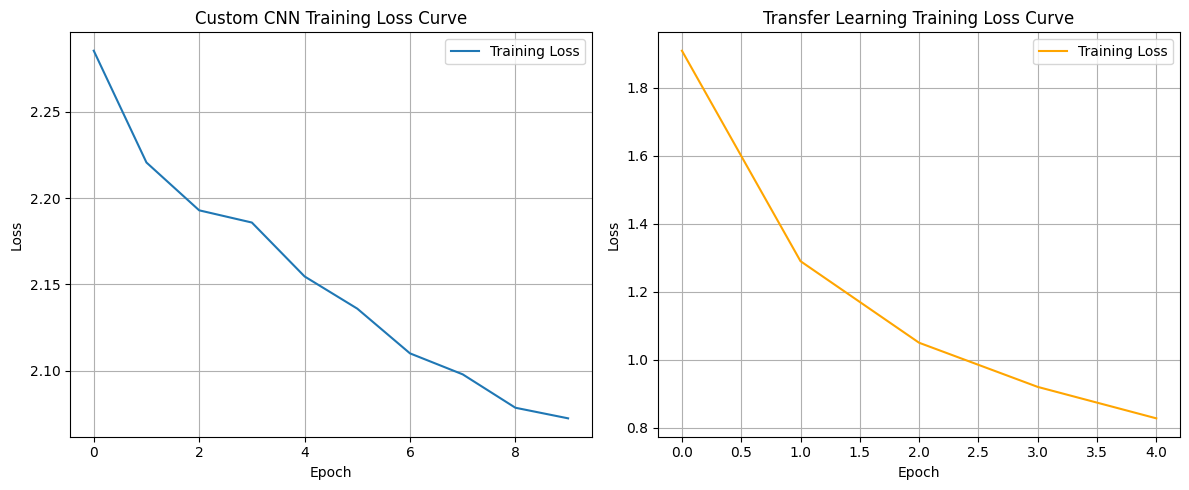

In [23]:
plt.figure(figsize=(12, 5))

# Plot Custom CNN Loss
plt.subplot(1, 2, 1)
plt.plot(custom_history['loss'], label='Training Loss')
plt.title('Custom CNN Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Transfer Learning Model Loss
plt.subplot(1, 2, 2)
plt.plot(tl_history['loss'], label='Training Loss', color='orange')
plt.title('Transfer Learning Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()